<a href="https://colab.research.google.com/github/YakubuNaat/Materials-Properties-Prediction-with-DFT-and-ML/blob/main/machine_learning_for_MOFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install xgboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/qmof_reduced.csv')

Mounted at /content/qmof_reduced.csv


In [ ]:
#!pip install pymatgen

In [ ]:
!pip install rdkit-pypi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 51.6 MB/s eta 0:00:00


In [ ]:
#!pip install mp-api

In [ ]:
!pip install xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score




In [ ]:
# prompt: import knn module , support vector mechanics , KNN

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
file_path = '/content/SavinoMandyNaat.csv'
df_cleaned = pd.read_csv(file_path)

In [ ]:
df_cleaned.shape

(96, 1792)

In [ ]:
columns_to_keep= ['MagpieData maximum Electronegativity', 'jml_nn_99', 'jml_nn_96',
       'n_symmetry_ops', 'jml_nn_97', 'jml_X_subs_hfus', 'jml_hfus_add_X', 'Fermi Level (eV)']
df = df_cleaned[columns_to_keep]
df.to_csv('filtered1.csv', index=False)

In [ ]:
from os import read
df= pd.read_csv('/content/filtered1.csv')

In [ ]:
df = df_cleaned.select_dtypes(include=np.number)

In [ ]:
df.shape

(96, 1783)

In [ ]:
df = df.dropna(subset=["Fermi Level (eV)"])

In [ ]:
df.shape

(95, 1783)

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.dtypes

,0
MagpieData minimum Number,float64
MagpieData maximum Number,float64
MagpieData range Number,float64
MagpieData mean Number,float64
MagpieData avg_dev Number,float64
...,...
jml_nn_96,float64
jml_nn_97,float64
jml_nn_98,float64
jml_nn_99,float64


In [ ]:
df = df.loc[:, df.nunique() > 2]

In [ ]:
df.shape

(95, 1130)

In [ ]:
columns_to_drop = [ 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0','CIF file','Atom CIF file', 'Total Energy (eV)', 'Dopant Energy (eV)',
                   'CO2 Slab Energy', 'HOMO (eV)', 'LUMO (eV)', 'Band Gap (eV)', 'Work Function (eV)', 'Chemical Potential (eV)',
                    'Entropy (eV/K)', 'Free Energy (eV)', 'Local Magnetic Moments',
                    'Total Magnetic Moment', 'Pristine Energy (eV)', 'Fe Atom Energy (eV)', 'filename']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

In [ ]:
df.shape

(95, 1130)

Highly correlated feature pairs (correlation > 0.90):
Dropped 'MagpieData minimum Number' as it is highly correlated with 'MagpieData minimum AtomicWeight' (0.99)
Dropped 'MagpieData maximum Number' as it is highly correlated with 'MagpieData range Number' (1.00)
Dropped 'MagpieData range Number' as it is highly correlated with 'MagpieData mean Number' (0.99)
Dropped 'MagpieData mean Number' as it is highly correlated with 'MagpieData avg_dev Number' (0.99)
Dropped 'MagpieData avg_dev Number' as it is highly correlated with 'MagpieData maximum AtomicWeight' (1.00)
Dropped 'MagpieData maximum MendeleevNumber' as it is highly correlated with 'MagpieData maximum Column' (0.99)
Dropped 'MagpieData range MendeleevNumber' as it is highly correlated with 'MagpieData avg_dev MendeleevNumber' (1.00)
Dropped 'MagpieData mean MendeleevNumber' as it is highly correlated with 'MagpieData mean Column' (0.92)
Dropped 'MagpieData maximum AtomicWeight' as it is highly correlated with 'MagpieData range 

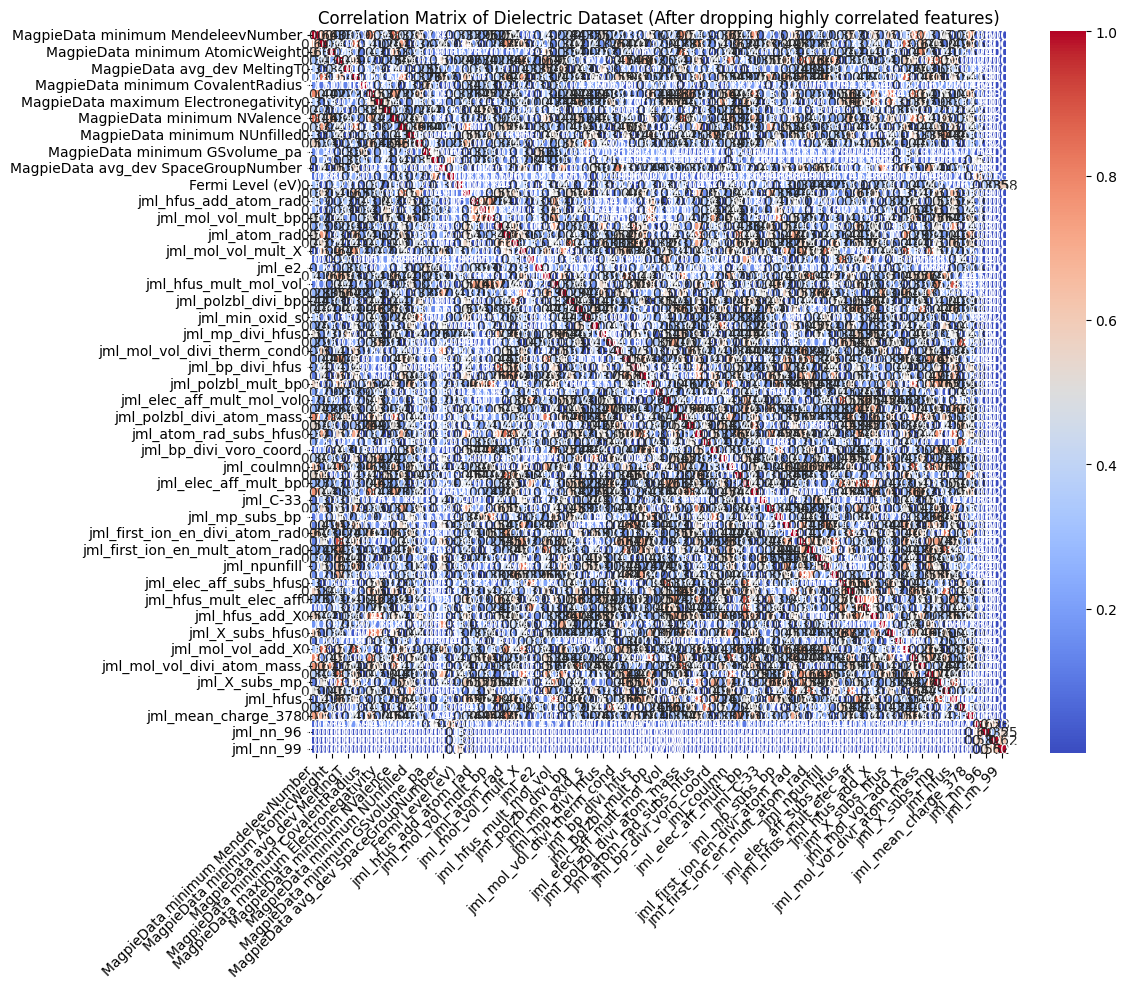

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load your dataset (if not already loaded)
# df = pd.read_csv("your_file.csv")

# Compute correlation matrix
correlation_matrix = df.corr().abs()

# Find and print highly correlated feature pairs (excluding self-correlation)
threshold = 0.90
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value > threshold:
            feature_1 = correlation_matrix.columns[i]
            feature_2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feature_1, feature_2, corr_value))

# Print highly correlated pairs and drop one from each pair
print("Highly correlated feature pairs (correlation > 0.90):")
dropped_columns = set() # Keep track of columns that have been dropped
for f1, f2, corr in high_corr_pairs:
  # Check if f1 is in df.columns AND f1 is not the target column AND f1 has not been dropped before
  # The original code had an incorrect comparison structure.
  if f1 in df.columns and f1 != "Fermi Level (eV)" and f1 not in dropped_columns:
    df.drop(f1, axis=1, inplace=True)
    dropped_columns.add(f1) # Add f1 to the set of dropped columns
    print(f"Dropped '{f1}' as it is highly correlated with '{f2}' ({corr:.2f})")

#Plot heatmap of the remaining columns (optional, as the matrix is from the original df)
#To plot the correlation matrix of the updated df, you would need to recompute it
correlation_matrix_updated = df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_updated, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Dielectric Dataset (After dropping highly correlated features)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# You can still plot the original correlation matrix as it was computed before dropping
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f") # annot=False for large matrices
# plt.title('Original Correlation Matrix of Dielectric Dataset')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

Highly correlated feature pairs (correlation > 0.90):


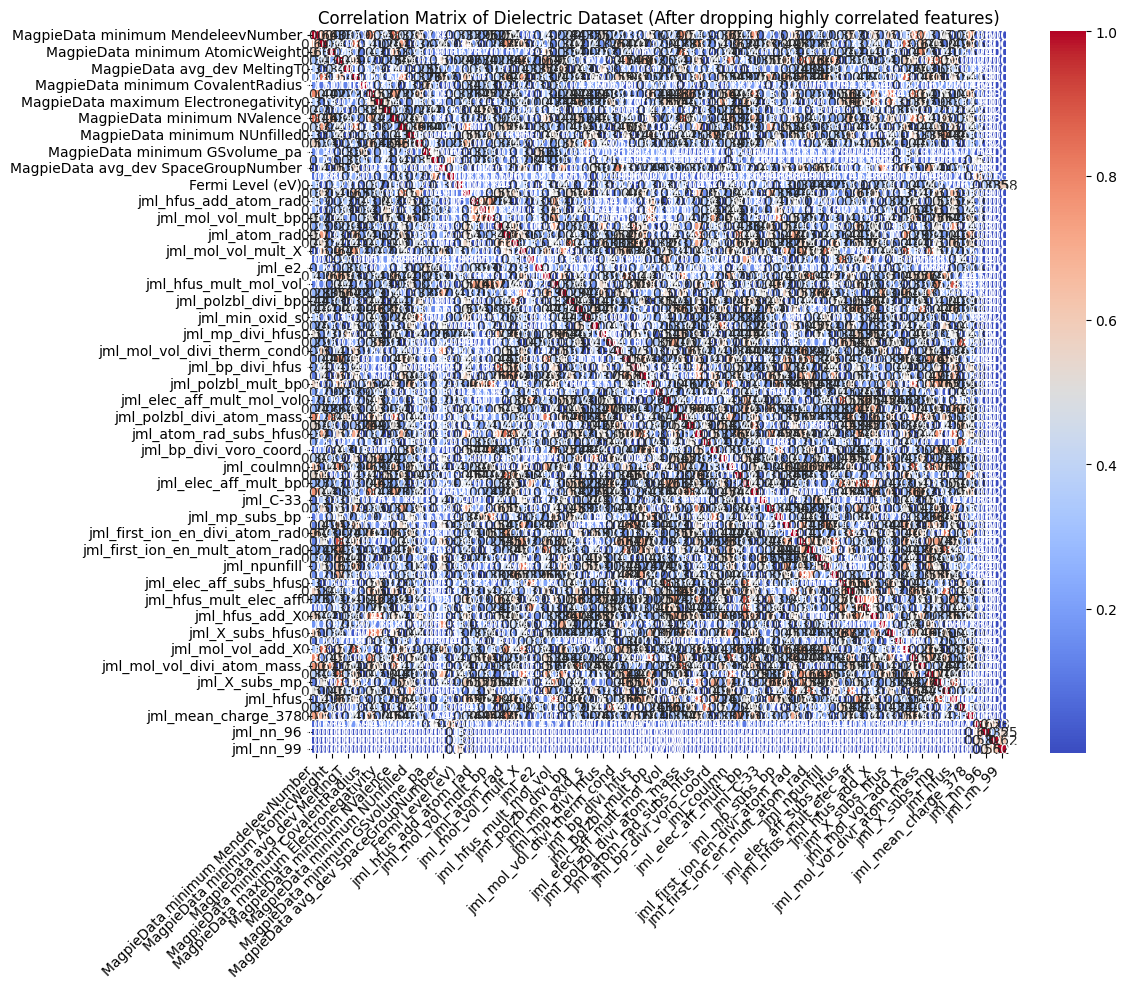

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load your dataset (if not already loaded)
# df = pd.read_csv("your_file.csv")

# Compute correlation matrix
correlation_matrix = df.corr().abs()

# Find and print highly correlated feature pairs (excluding self-correlation)
threshold = 0.90
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value > threshold:
            feature_1 = correlation_matrix.columns[i]
            feature_2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feature_1, feature_2, corr_value))

# Print highly correlated pairs and drop one from each pair
print("Highly correlated feature pairs (correlation > 0.90):")
dropped_columns = set() # Keep track of columns that have been dropped
for f1, f2, corr in high_corr_pairs:
  # Check if f1 is in df.columns AND f1 is not the target column AND f1 has not been dropped before
  # The original code had an incorrect comparison structure.
  if f1 in df.columns and f1 != "Fermi Level (eV)" and f1 not in dropped_columns:
    df.drop(f1, axis=1, inplace=True)
    dropped_columns.add(f1) # Add f1 to the set of dropped columns
    print(f"Dropped '{f1}' as it is highly correlated with '{f2}' ({corr:.2f})")

#Plot heatmap of the remaining columns (optional, as the matrix is from the original df)
#To plot the correlation matrix of the updated df, you would need to recompute it
correlation_matrix_updated = df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_updated, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Dielectric Dataset (After dropping highly correlated features)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# You can still plot the original correlation matrix as it was computed before dropping
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f") # annot=False for large matrices
# plt.title('Original Correlation Matrix of Dielectric Dataset')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

In [ ]:
df.shape

(95, 87)

In [ ]:
# Example: Capping outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Convert categorical variables to numerical using one-hot encoding
df_cleaned = pd.get_dummies(df_cleaned, drop_first=True)
print(df_cleaned.shape)



(8, 93)


In [ ]:
df_cleaned = pd.get_dummies(df, drop_first=True)
print(df_cleaned.shape)


(95, 87)


In [ ]:
##scalling the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

# Convert back to DataFrame for easier manipulation
df_scaled = pd.DataFrame(df_scaled, columns=df_cleaned.columns)
# Ensure all columns are the correct data type
df_scaled = df_scaled.astype(float)
# print(df_cleaned) # Example: Convert all to float if necessary



In [ ]:
models = {
    #"Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=300, max_depth=10),
    #"Support Vector Machine": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

In [ ]:
# Assuming 'target' is your target column and it's binary
X = df_scaled.drop('Fermi Level (eV)' , axis = 1 )
y = df_scaled['Fermi Level (eV)']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the results dictionary
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_squared_error(y_test, y_pred)
    }

In [ ]:
import pandas as pd
import numpy as np

# Suppose X and y are pandas DataFrames or arrays
# If they are NumPy arrays, convert X to a DataFrame to print it nicely
X_df = pd.DataFrame(X, columns=feature_names)  # replace feature_names if needed
y_series = pd.Series(y)

# Target Fermi level value
target_value = -1.2227

# Get the rows (features) where y equals the target
matching_rows = X_df[y_series == target_value]

# Print the results
print(f"Features (X values) corresponding to target Fermi level = {target_value}:\n")
print(matching_rows)


Features (X values) corresponding to target Fermi level = -1.2227:

Empty DataFrame
Columns: [MagpieData maximum Electronegativity, jml_nn_99, jml_nn_96, n_symmetry_ops, jml_nn_97, jml_X_subs_hfus, jml_hfus_add_X]
Index: []


In [ ]:
sample = np.array([[1.83,0.0,2.0,6,2,1.5564,1.8236]])
for name, model in models.items():
    prediction = model.predict(sample)
    print(f"{name} Prediction: {prediction[0]:.4f}")

Decision Tree Prediction: -0.5515
Random Forest Prediction: -0.3549
K-Nearest Neighbors Prediction: -0.5022


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


/tmp/ipython-input-2344206380.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', len(model_names))  # You can choose other colormaps


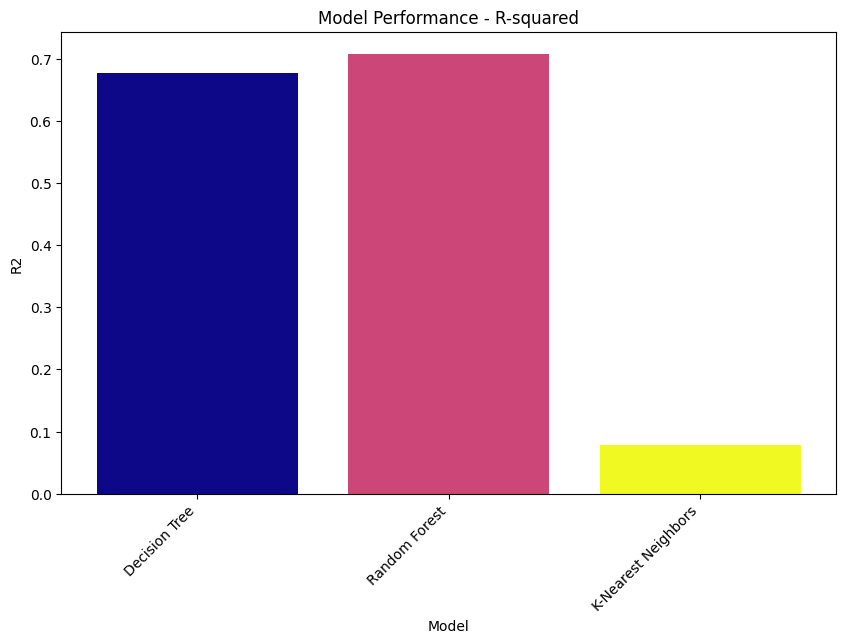

In [ ]:

def plot_metric(metric, title):
    plt.figure(figsize=(10, 6))
    model_names = list(results.keys())
    metric_values = [results[name][metric] for name in model_names]

    # Generate a color for each bar
    colors = plt.cm.get_cmap('plasma', len(model_names))  # You can choose other colormaps

    plt.bar(model_names, metric_values, color=colors(np.arange(len(model_names))))
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.show()


plot_metric("R2", "Model Performance - R-squared")



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

def plot_metric_3d(metric, title, results):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    model_names = list(results.keys())
    metric_values = [results[name][metric] for name in model_names]

    # Bar positions
    xpos = np.arange(len(model_names))
    ypos = np.zeros_like(xpos)
    zpos = np.zeros_like(xpos)

    # Bar dimensions
    dx = dy = 0.5
    dz = metric_values

    # Color map
    colors = plt.cm.plasma(np.linspace(0, 1, len(model_names)))

    # Plot bars
    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors)

    # Add R² labels as percentages
    for i, val in enumerate(metric_values):
        ax.text(xpos[i], ypos[i], dz[i] + 0.01, f"{val * 100:.1f}%", ha='center', va='bottom', fontsize=10)

    # Set axes
    ax.set_xticks(xpos)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_yticks([])
    ax.set_zlabel(metric)
    ax.set_title(title, pad=20)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-4036067899.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


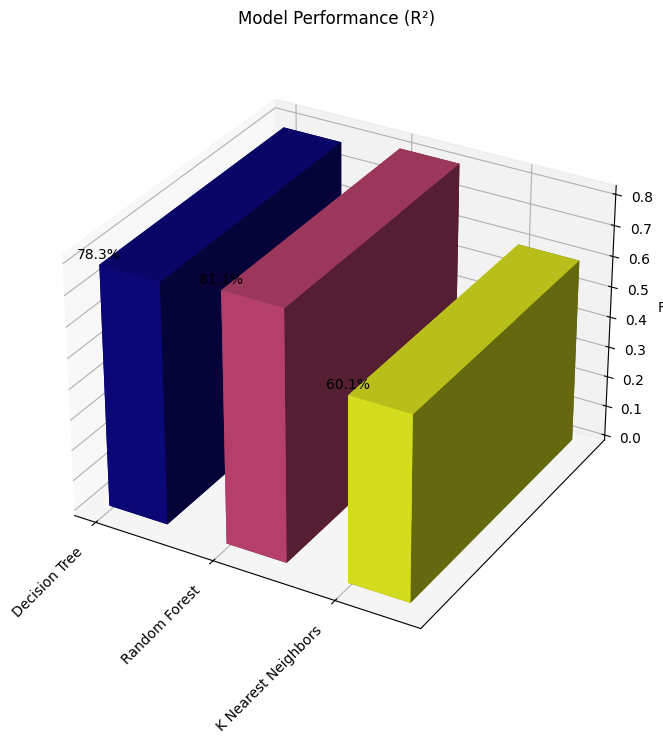

In [ ]:
results = {
    'Decision Tree': {'R2': 0.782866},
    'Random Forest': {'R2': 0.811434},
    'K Nearest Neighbors': {'R2': 0.600711}
}

plot_metric_3d("R2", "Model Performance (R²)", results)

<ipython-input-428-2344206380>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', len(model_names))  # You can choose other colormaps


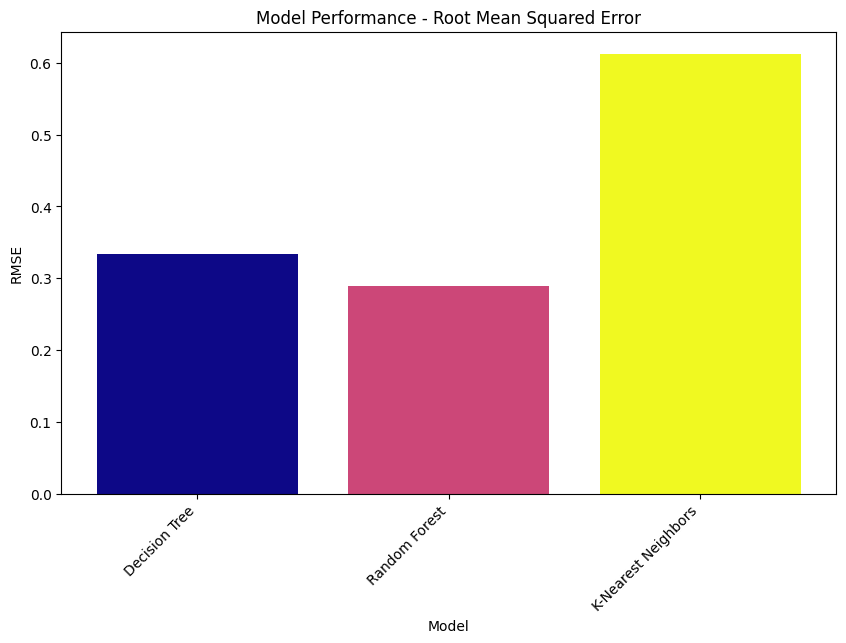

In [ ]:
plot_metric("RMSE", "Model Performance - Root Mean Squared Error")

<ipython-input-428-2344206380>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', len(model_names))  # You can choose other colormaps


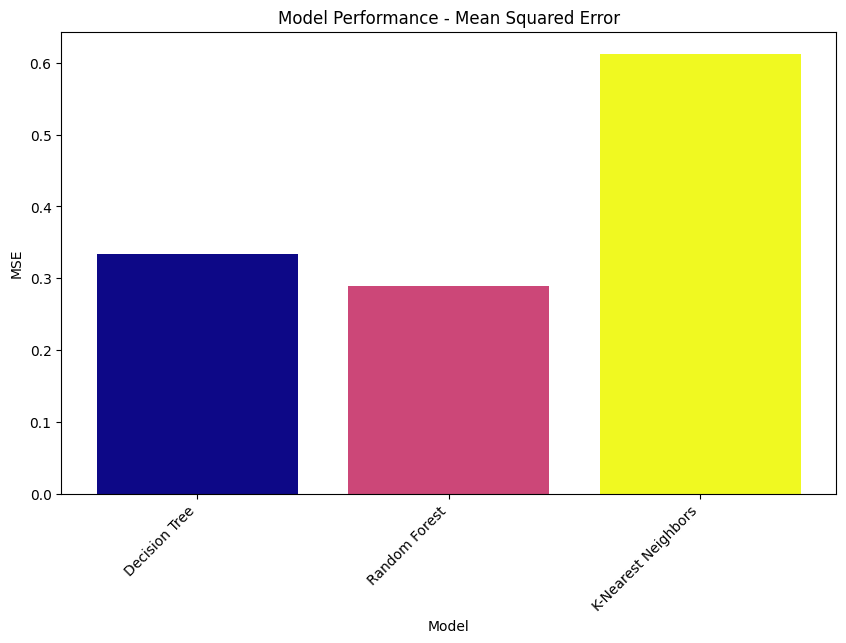

In [ ]:
plot_metric("MSE", "Model Performance - Mean Squared Error")

<ipython-input-428-2344206380>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', len(model_names))  # You can choose other colormaps


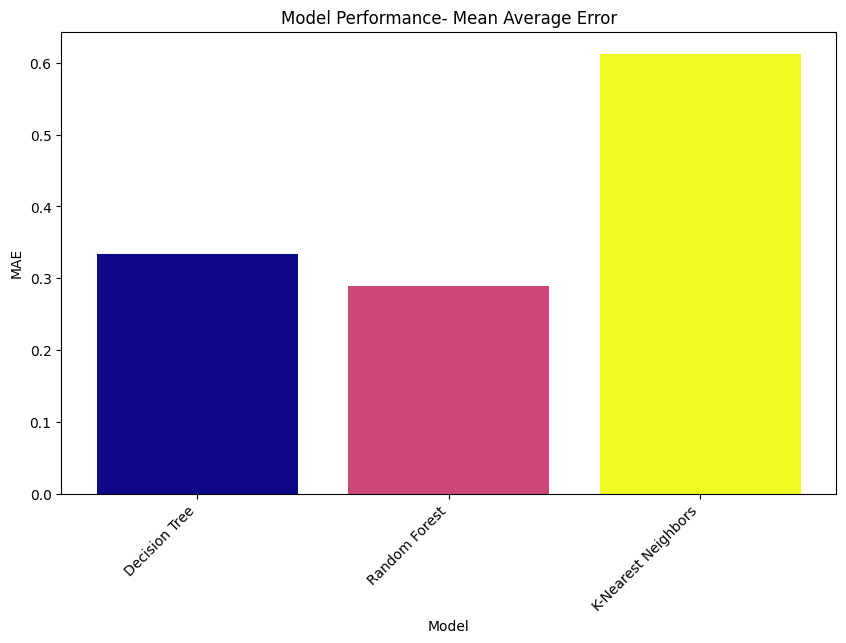

In [ ]:
plot_metric("MAE", "Model Performance- Mean Average Error")

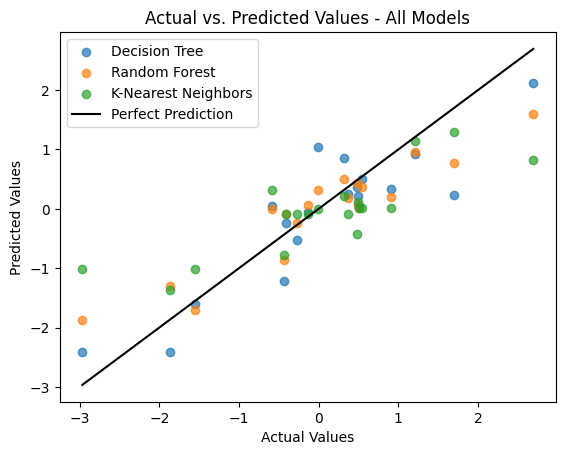

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.scatter(y_test, y_pred, label=name, alpha=0.7)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values - All Models")

# Add a diagonal line for reference
min_val = min(min(y_test), min([min(model.predict(X_test)) for model in models.values()]))
max_val = max(max(y_test), max([max(model.predict(X_test)) for model in models.values()]))
plt.plot([min_val, max_val], [min_val, max_val], 'k', label="Perfect Prediction")

plt.legend()
plt.show()

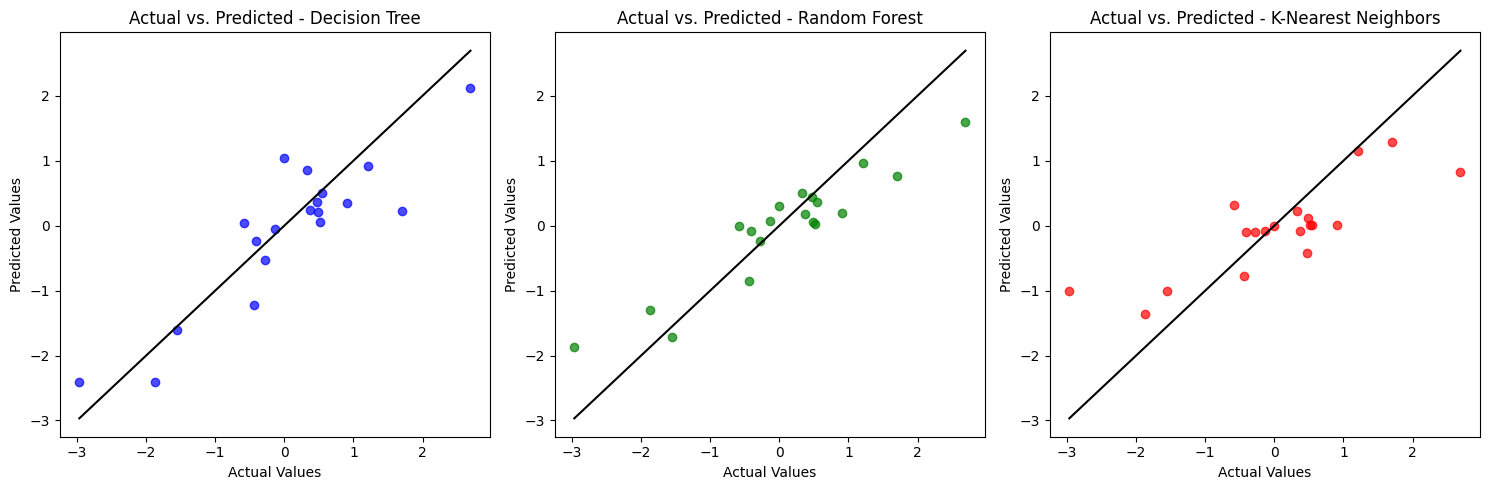

In [ ]:
##Predicted against actual,  graph for all the models individually

# Number of models
num_models = len(models)

# Calculate number of rows and columns for subplots
num_cols = 3  # Adjust as needed
num_rows = (num_models + num_cols - 1) // num_cols

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten for easy iteration

# Colors for each model
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'cyan']

# Plot each model individually
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    axes[i].scatter(y_test, y_pred, alpha=0.7, color=colors[i % len(colors)])
    axes[i].set_xlabel("Actual Values")
    axes[i].set_ylabel("Predicted Values")
    axes[i].set_title(f"Actual vs. Predicted - {name}")

    # Diagonal line for reference
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'k')

# Hide any unused subplots
for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
##The same this as the line 82 one what differs is the MAE
for i,j in results.items():
  print(f"{i} - R2: {j['R2']}, MSE: {j['MSE']}, RMSE: {j['RMSE']}, MAE: {j['MAE']}")

Decision Tree - R2: 0.7828658105878445, MSE: 0.3331478465436638, RMSE: 0.3331478465436638, MAE: 0.3331478465436638
Random Forest - R2: 0.8114339573921441, MSE: 0.28931588892629356, RMSE: 0.28931588892629356, MAE: 0.28931588892629356
K-Nearest Neighbors - R2: 0.6007107060206897, MSE: 0.6126274669008914, RMSE: 0.6126274669008914, MAE: 0.6126274669008914


In [ ]:

from tabulate import tabulate

In [ ]:


# Prepare data for the table
table_data = []
for i, j in results.items():
    table_data.append([i, j['R2'], j['MSE'], j['RMSE'], j['MAE']])

# Define table headers
headers = ["Model", "R2", "MSE", "RMSE", "MAE"]

# Print the table
print(tabulate(table_data, headers=headers, tablefmt="grid"))

+---------------------+----------+----------+----------+----------+
| Model               |       R2 |      MSE |     RMSE |      MAE |
+=====================+==========+==========+==========+==========+
| Decision Tree       | 0.782866 | 0.333148 | 0.333148 | 0.333148 |
+---------------------+----------+----------+----------+----------+
| Random Forest       | 0.811434 | 0.289316 | 0.289316 | 0.289316 |
+---------------------+----------+----------+----------+----------+
| K-Nearest Neighbors | 0.600711 | 0.612627 | 0.612627 | 0.612627 |
+---------------------+----------+----------+----------+----------+


In [ ]:
from sklearn.linear_model import Ridge
#from sklearn.model_selection import train_test_split
#import numpy as np

# Assume X and y are your features and target variable
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Ridge regression model with L2 regularization
# The alpha parameter controls the strength of the regularization.
# A larger alpha means stronger regularization.
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred = ridge_model.predict(X_test)

# Evaluate the model (e.g., using mean squared error)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with Ridge Regression: {mse}")

Mean Squared Error with Ridge Regression: 0.7669772043932376


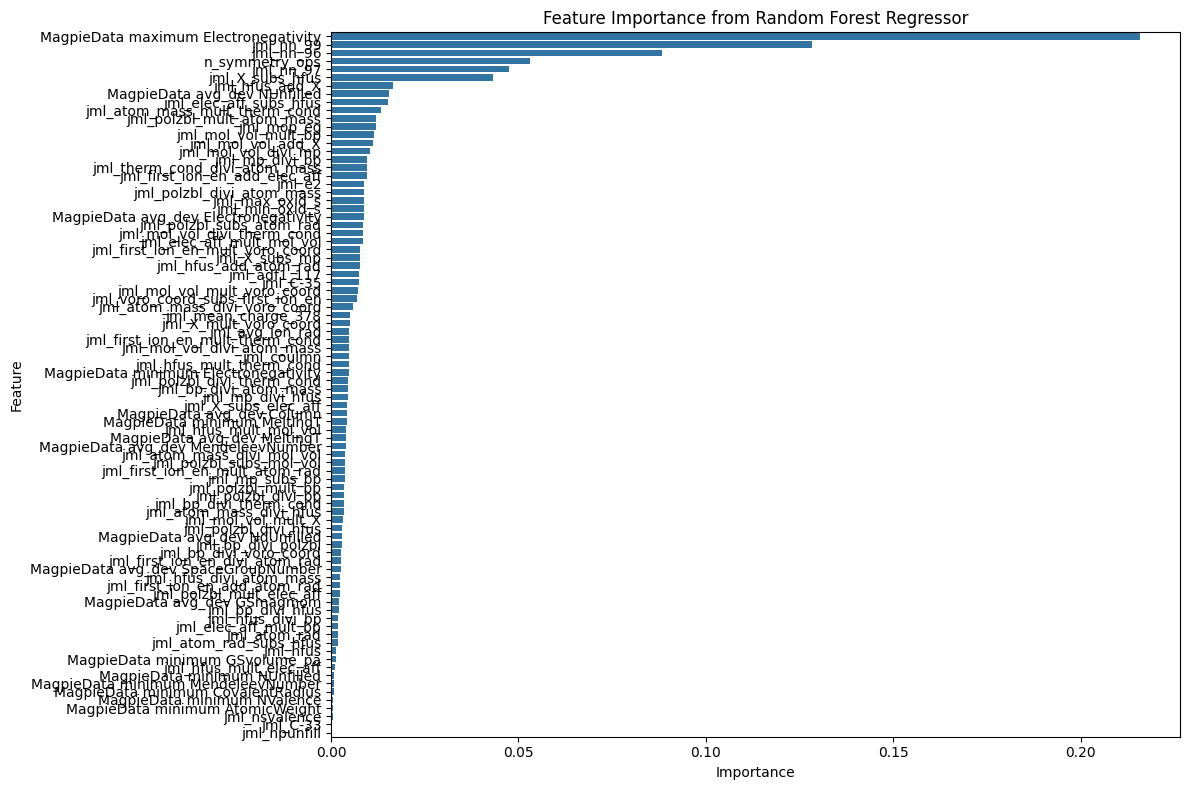

In [ ]:
# Get the trained Random Forest model from the models dictionary
rf_model = models["Random Forest"]

# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

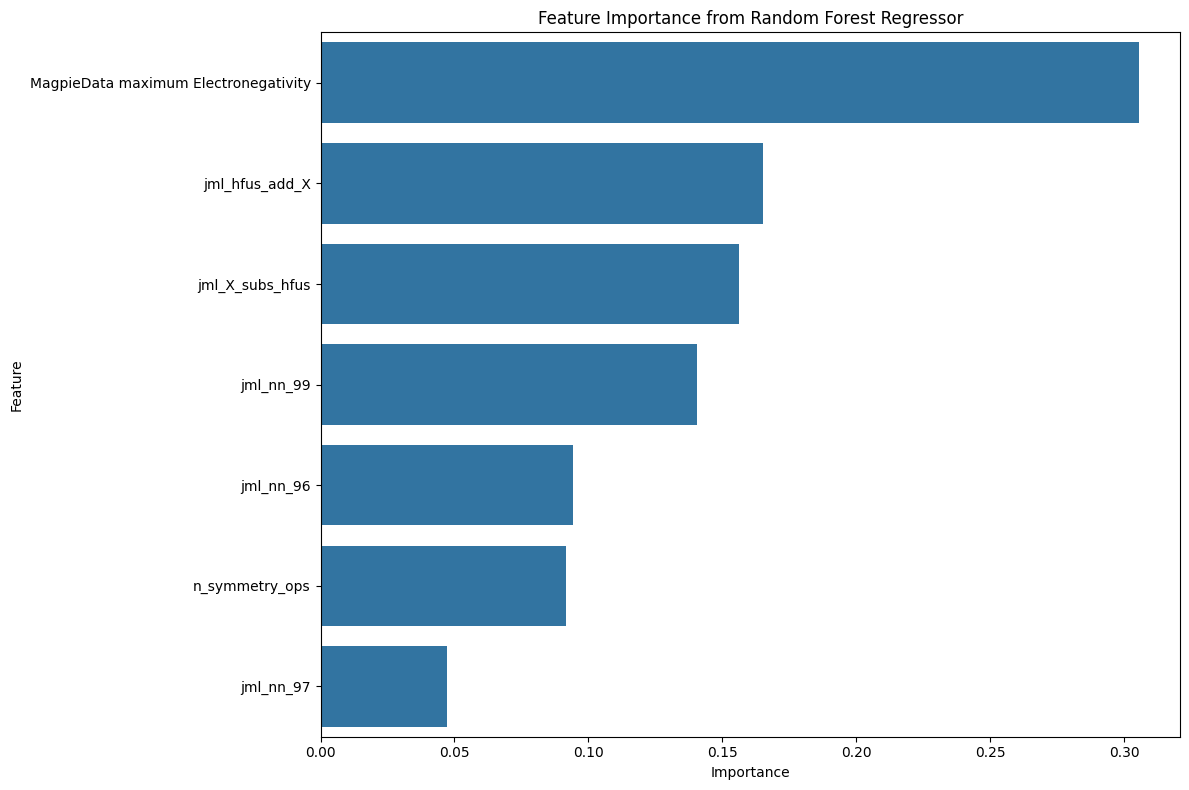

In [ ]:
# Get the trained Random Forest model from the models dictionary
rf_model = models["Random Forest"]

# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Filter out features with importance > 0.02
important_features = feature_importance_df[feature_importance_df['importance'] > 0.02]['feature'].tolist()

# Drop unimportant features from X_train and X_test
X_train_filtered = X_train[important_features]
X_test_filtered = X_test[important_features]

# Optional: Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df[feature_importance_df['importance'] > 0.02])
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
X_train_filtered.columns

Index(['MagpieData maximum Electronegativity', 'jml_hfus_add_X',
       'jml_X_subs_hfus', 'jml_nn_99', 'jml_nn_96', 'n_symmetry_ops',
       'jml_nn_97'],
      dtype='object')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor # Also ensure RandomForestRegressor is imported if not already


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],  # Number of trees in the forest
    "max_depth": [None, 10, 20, 30],  # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],  # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],  # Minimum samples required in a leaf
    "bootstrap": [True, False],  # Whether bootstrap samples are used
}

# RandomizedSearchCV to find the best hyperparameters
rfr = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rfr, param_distributions=param_grid,
                                   n_iter=100, cv=5, verbose=1, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best model
best_rfr = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Training the best model
best_rfr.fit(X_train, y_train)

# Predictions
y_pred = best_rfr.predict(X_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}


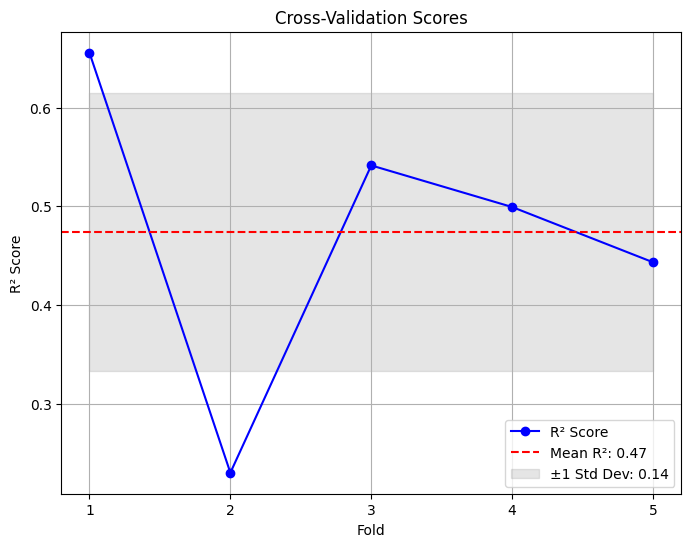

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Create a RandomForestRegressor instance (definition moved from cell s3IYbr9FhWu0)
rfr = RandomForestRegressor(random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rfr, X_train, y_train, cv=cv, scoring='r2')

# Visualization of Cross-Validation Scores
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='-', color='b', label='R² Score')
plt.axhline(np.mean(cv_scores), color='r', linestyle='--', label=f'Mean R²: {np.mean(cv_scores):.2f}')
plt.fill_between(range(1, len(cv_scores) + 1),
                 np.mean(cv_scores) - np.std(cv_scores),
                 np.mean(cv_scores) + np.std(cv_scores),
                 color='gray', alpha=0.2, label=f'±1 Std Dev: {np.std(cv_scores):.2f}')

plt.title('Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**NOTE FOR CHOOSING BETTER MODEL OR MODEL THAT PERFORMED WELL**

Understanding the Metrics:

    Lower is Better: For MSE and RMSE, lower values indicate better performance. These metrics measure the average error between predicted and actual values, so smaller errors are desirable.
    Higher is Better: For R2, higher values indicate better performance. R2 represents the proportion of variance in the target variable explained by the model. A value closer to 1 means the model captures more of the underlying patterns in the data.

Comparing Models:

    Direct Comparison: Look at the metrics for each model side-by-side. Identify the models with the lowest MSE/RMSE and the highest R2.
    Relative Importance: Consider which metric is most important for your specific problem.
        If minimizing prediction errors is crucial, focus on MSE or RMSE.
        If understanding the overall explanatory power of the model is key, prioritize R2.
    Trade-offs: Sometimes there's a trade-off between metrics. A model with slightly higher MSE might have a significantly better R2, indicating a better overall fit despite slightly larger errors.
    Context Matters: The "best" model depends on your specific goals and the acceptable level of error in your application.


**                          here is the entire machine learning for the mofs**

##NOMAD method

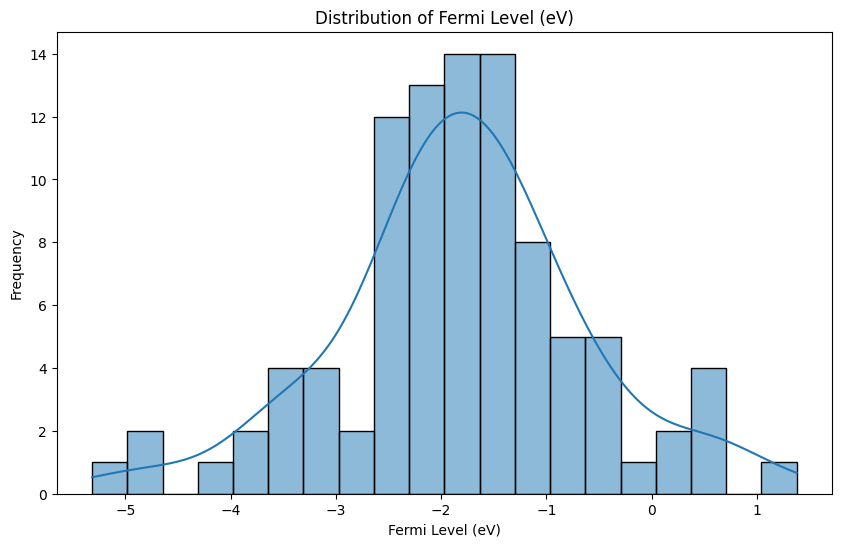

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fermi Level (eV)'], kde=True, bins=20)
plt.title('Distribution of Fermi Level (eV)')
plt.xlabel('Fermi Level (eV)')
plt.ylabel('Frequency')
plt.show()